
# K-Means Clustering (KMeans) con California Housing (sklearn)
**Objetivo:** construir un ejemplo completo y autocontenido de clustering con **K-Means** sobre el dataset **California Housing**, incorporando **buenas prácticas**, selección de **número de clusters** con **método del codo** e **índice de silueta**, y gráficos asociados.  
Además, se discute y aplica cuándo conviene **estandarización** y **PCA**.

> Nota: California Housing fue creado para regresión (precio de vivienda). Aquí lo usamos como ejemplo didáctico de *segmentación*; por eso el foco está en estructura de datos y variables explicativas, no en predecir el target.


In [1]:

# =========================
# 0) Setup e imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Reproducibilidad
RANDOM_STATE = 42

# (Opcional) Mejoras estéticas para gráficos (sin fijar colores explícitos)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Listo ✅")


Listo ✅


In [2]:

# =========================
# 1) Cargar dataset
# =========================
cal = fetch_california_housing(as_frame=True)
X = cal.data.copy()
y = cal.target.copy()  # MedHouseVal

print("Shape X:", X.shape)
display(X.head())


Shape X: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



## 2) Buenas prácticas antes de K-Means

K-Means asume implícitamente:
- Distancias euclidianas son significativas.
- Clusters aproximadamente esféricos y de varianza similar.
- Variables comparables en escala.

**Por eso:**
1. **Estandarización** suele ser necesaria (muy recomendada) cuando las features están en escalas diferentes.
2. Revisar **outliers** (pueden “tirar” centroides).
3. Usar `k-means++`, varios reinicios (`n_init`) y fijar `random_state` para reproducibilidad.
4. Evaluar `k` con **codo** (inercia) y **silueta** (cohesión/separación).
5. **PCA**:
   - Útil para **visualización** en 2D/3D.
   - Útil para **reducción de ruido / colinealidad** cuando hay variables correlacionadas.
   - No es obligatoria para K-Means, pero suele ayudar en datasets con alta correlación o si quieres clusters “más compactos” en un subespacio.

En este notebook:
- Entrenamos K-Means sobre **X estandarizado**.
- Usamos **PCA(2)** principalmente para visualizar.
- (Opcional) Comparamos K-Means sobre PCA vs sin PCA.


In [3]:

# =========================
# 3) Estandarización
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificación rápida: media ~0, std ~1
print("Medias (aprox):", np.round(X_scaled.mean(axis=0), 3))
print("Std (aprox):   ", np.round(X_scaled.std(axis=0), 3))


Medias (aprox): [ 0.  0.  0. -0. -0.  0.  0. -0.]
Std (aprox):    [1. 1. 1. 1. 1. 1. 1. 1.]


Varianza explicada por PC1+PC2: 0.489
Detalle: [0.253 0.235]


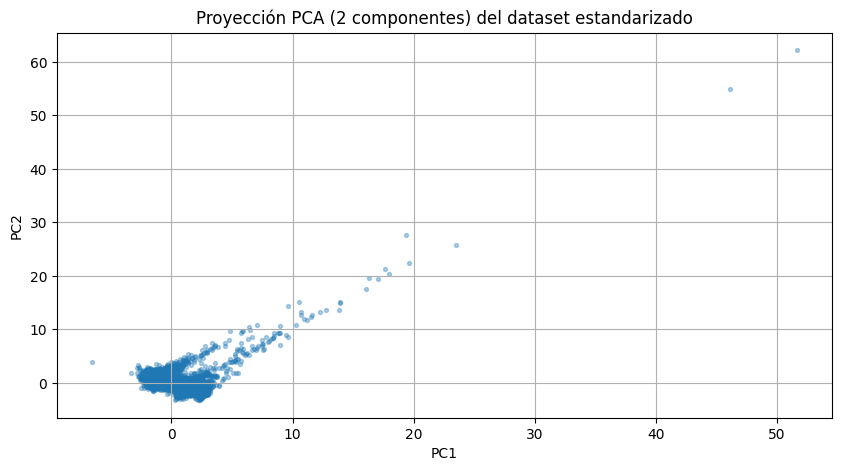

In [4]:

# =========================
# 4) PCA para visualización + varianza explicada
# =========================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1+PC2: {explained.sum():.3f}")
print("Detalle:", np.round(explained, 3))

plt.figure()
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=8, alpha=0.35)
plt.title("Proyección PCA (2 componentes) del dataset estandarizado")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



## 5) Selección de *k*: Codo e Índice de Silueta

- **Codo (Inercia / SSE)**: suma de distancias cuadradas a centroides. Disminuye al aumentar *k*. Buscamos un punto de rendimientos decrecientes.
- **Silueta**: toma valores en [-1, 1]. Más alto suele indicar clusters mejor separados y compactos.  
  - Regla práctica: > 0.5 suele ser “bueno”, 0.2–0.5 “razonable”, < 0.2 sugiere estructura débil para clustering euclidiano.

**Importante:** no siempre ambos coinciden. En casos reales se complementa con interpretabilidad del negocio y estabilidad del clustering.


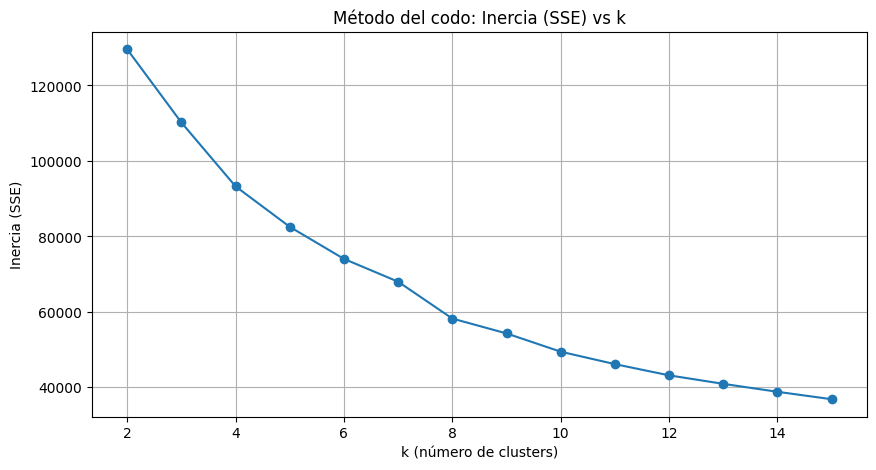

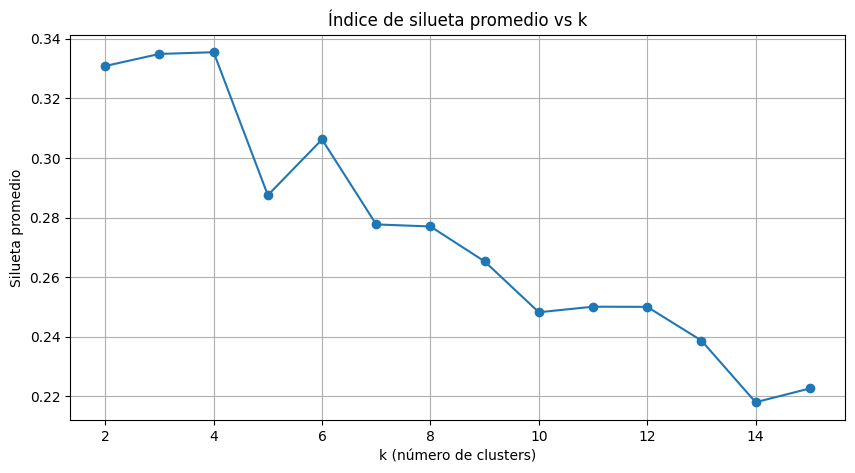

,k,inertia,silhouette
2,4,93278.180340,0.335469
1,3,110213.282677,0.334897
0,2,129613.192133,0.330847
4,6,74052.659118,0.306203
3,5,82550.923819,0.287486
5,7,68005.304665,0.277682
6,8,58239.638132,0.276998
7,9,54301.174156,0.265270
9,11,46159.863634,0.250075
10,12,43187.914027,0.250017


In [5]:

# =========================
# 5A) Barrido de k: inercia (codo) + silueta
# =========================
k_values = list(range(2, 16))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# --- Gráfico codo
plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.title("Método del codo: Inercia (SSE) vs k")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.show()

# --- Gráfico silueta
plt.figure()
plt.plot(k_values, silhouettes, marker="o")
plt.title("Índice de silueta promedio vs k")
plt.xlabel("k (número de clusters)")
plt.ylabel("Silueta promedio")
plt.show()

# Resumen tabular
metrics_df = pd.DataFrame({"k": k_values, "inertia": inertias, "silhouette": silhouettes})
display(metrics_df.sort_values("silhouette", ascending=False).head(10))


In [6]:

# =========================
# 5B) Selección automática (heurística) de k
# =========================
# Heurística simple: elegir k que maximiza silueta.
# En práctica podrías restringir k por interpretabilidad o por el codo.
best_k = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
best_sil = float(metrics_df["silhouette"].max())

print(f"Mejor k por silueta (heurística): k={best_k} con silueta={best_sil:.3f}")


Mejor k por silueta (heurística): k=4 con silueta=0.335



## 6) Entrenar K-Means con el *k* seleccionado y analizar clusters

Aquí:
- Ajustamos KMeans sobre **X_scaled**.
- Visualizamos clusters en el plano PCA(2) (solo para interpretación visual).
- Hacemos un **perfil** por cluster: medias de variables originales (y estandarizadas), tamaño del cluster, etc.

> Sugerencia: si el dataset es grande y necesitas velocidad, considera `MiniBatchKMeans`.


In [7]:

# =========================
# 6A) Entrenar KMeans final
# =========================
k_final = best_k  # puedes fijarlo manualmente si lo prefieres
kmeans = KMeans(
    n_clusters=k_final,
    init="k-means++",
    n_init=50,
    max_iter=1000,
    random_state=RANDOM_STATE
)

labels = kmeans.fit_predict(X_scaled)

print("Inercia final:", round(kmeans.inertia_, 2))
print("Silueta final:", round(silhouette_score(X_scaled, labels), 3))

# Agregar labels al DataFrame original (para perfilamiento)
df = X.copy()
df["cluster"] = labels
df["MedHouseVal"] = y  # opcional para ver cómo varía el target por cluster (solo descriptivo)
df.head()


Inercia final: 93278.18
Silueta final: 0.335


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,cluster,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0,3.422


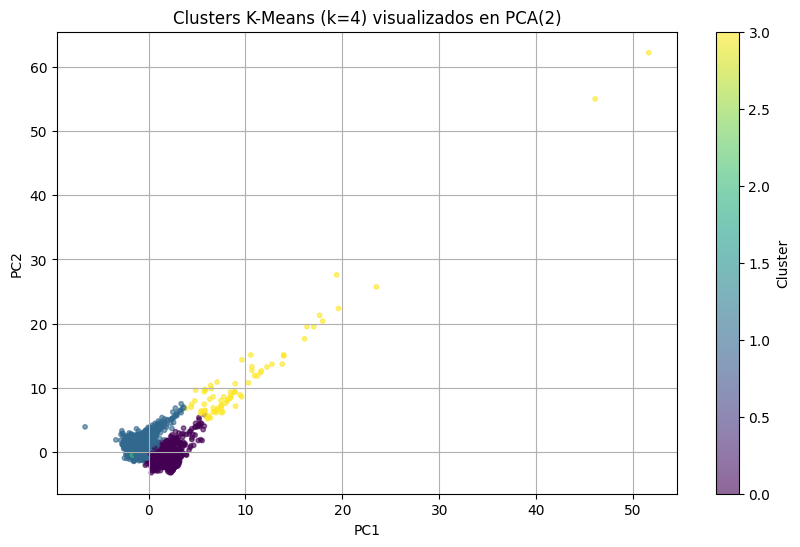

In [8]:

# =========================
# 6B) Visualización en 2D usando PCA
# =========================
# Proyectamos al plano PCA ya calculado (X_pca2 corresponde al mismo orden de filas de X)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels, s=10, alpha=0.6)
plt.title(f"Clusters K-Means (k={k_final}) visualizados en PCA(2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


In [9]:

# =========================
# 6C) Perfilamiento de clusters
# =========================
cluster_sizes = df["cluster"].value_counts().sort_index()
print("Tamaño por cluster:")
display(cluster_sizes.to_frame("n"))

# Promedios por cluster (variables originales)
profile_means = df.groupby("cluster").mean(numeric_only=True)
display(profile_means)

# (Opcional) ordenar clusters por MedHouseVal promedio (descriptivo)
display(profile_means[["MedHouseVal"]].sort_values("MedHouseVal", ascending=False))


Tamaño por cluster:


,n
cluster,
0,8627
1,11935
2,3
3,75


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
cluster,,,,,,,,,
0,3.804135,29.027008,5.503493,1.081950,1286.128086,2.824753,37.950009,-121.730083,1.973423
1,3.921187,28.418182,5.207149,1.071848,1532.163469,3.056250,33.942571,-118.008752,2.140146
2,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000
3,3.373379,18.733333,32.149384,6.741434,291.360000,2.497688,37.710133,-119.408267,1.628373


,MedHouseVal
cluster,
1,2.140146
0,1.973423
2,1.850000
3,1.628373



## 7) Diagnóstico adicional: gráfico de silueta por muestra (opcional)

El promedio de silueta ayuda a elegir *k*, pero el **diagrama de silueta** permite ver:
- Si hay clusters con muchas muestras mal asignadas (silueta baja o negativa).
- Balance de tamaños.
- Separación global.

Esto es útil para validar si K-Means es razonable en tu dataset.


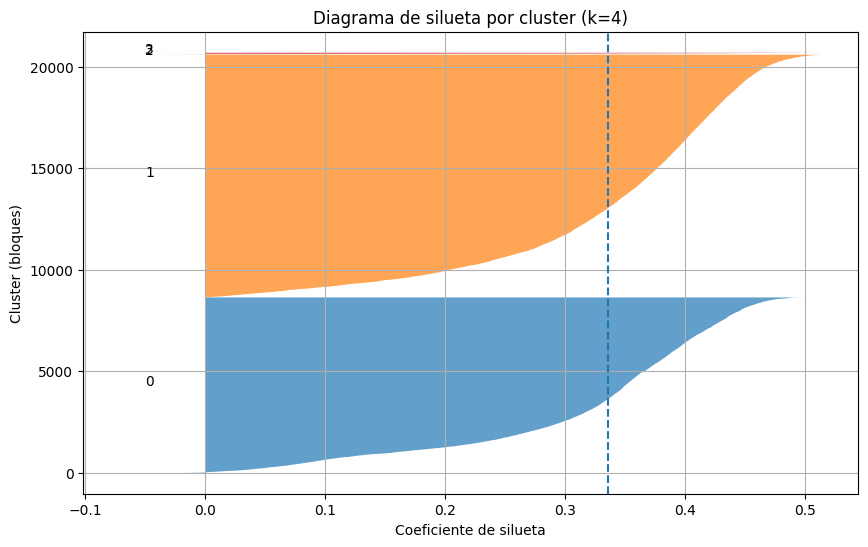

Silueta promedio: 0.335
Percentiles silueta: [0.092 0.29  0.361 0.413 0.463]


In [10]:

# =========================
# 7) Silhouette plot (por muestra)
# =========================
sample_silhouette_values = silhouette_samples(X_scaled, labels)

y_lower = 10
plt.figure(figsize=(10, 6))

for i in range(k_final):
    ith_vals = sample_silhouette_values[labels == i]
    ith_vals.sort()

    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))

    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_silhouette_values), linestyle="--")
plt.title(f"Diagrama de silueta por cluster (k={k_final})")
plt.xlabel("Coeficiente de silueta")
plt.ylabel("Cluster (bloques)")
plt.show()

print("Silueta promedio:", round(np.mean(sample_silhouette_values), 3))
print("Percentiles silueta:", np.round(np.percentile(sample_silhouette_values, [5, 25, 50, 75, 95]), 3))



## 8) (Opcional) ¿Conviene entrenar K-Means en PCA?

En algunos casos, K-Means sobre PCA puede:
- mejorar separación si hay colinealidad/ruido,
- reducir dimensionalidad y costo computacional,
- producir clusters más “compactos” en el subespacio.

Pero también puede **perder información** si recortas demasiada varianza.
A continuación comparamos (rápidamente) silueta/inercia en el espacio original estandarizado vs PCA con `n_components` variables.


In [11]:

# =========================
# 8) Comparativa KMeans: X_scaled vs PCA(n)
# =========================
components_list = [2, 3, 4, 5, 6, 8]  # ajustable
rows = []

for n_comp in components_list:
    pca_n = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca_n = pca_n.fit_transform(X_scaled)

    km = KMeans(
        n_clusters=k_final,
        init="k-means++",
        n_init=30,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    lbl = km.fit_predict(X_pca_n)
    sil = silhouette_score(X_pca_n, lbl)
    rows.append({
        "space": f"PCA({n_comp})",
        "explained_var": pca_n.explained_variance_ratio_.sum(),
        "inertia": km.inertia_,
        "silhouette": sil
    })

# baseline
km_base = KMeans(
    n_clusters=k_final,
    init="k-means++",
    n_init=30,
    max_iter=500,
    random_state=RANDOM_STATE
)
lbl_base = km_base.fit_predict(X_scaled)
rows.insert(0, {
    "space": "Scaled (original)",
    "explained_var": 1.0,
    "inertia": km_base.inertia_,
    "silhouette": silhouette_score(X_scaled, lbl_base)
})

compare_df = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
display(compare_df)


,space,explained_var,inertia,silhouette
1,PCA(2),0.488531,20726.546824,0.602561
2,PCA(3),0.647417,42921.610842,0.415182
4,PCA(5),0.901679,77335.290147,0.383609
5,PCA(6),0.984102,90656.782535,0.343706
3,PCA(4),0.776297,62786.951839,0.343416
6,PCA(8),1.000000,93278.180340,0.335469
0,Scaled (original),1.000000,93278.180340,0.335469



## 9) Conclusiones y checklist de mejores prácticas

**Checklist (práctico):**
- ✅ **Escalar** variables antes de K-Means (StandardScaler).
- ✅ Probar varios *k* y usar **codo + silueta** (no uno solo).
- ✅ Aumentar `n_init` y fijar `random_state` para estabilidad.
- ✅ Validar con **perfilamiento** (medias/medianas por cluster) y sentido del negocio.
- ✅ Usar **PCA para visualizar** y (si mejora métricas) considerar entrenar en PCA.
- ✅ Si hay muchos outliers o clusters no esféricos, probar alternativas: **GMM**, **DBSCAN/HDBSCAN**, **K-Medoids**, **Spectral Clustering**.

**Interpretación rápida:**  
Si la silueta máxima es baja (<0.2), puede indicar que el dataset no tiene clusters claros bajo distancia euclidiana, o que necesitas:
- ingeniería de features,
- transformación no lineal,
- otro algoritmo de clustering.

¡Listo!
